In [1]:
import os
from typing import List

import pandas as pd
import numpy as np
import scanpy as sc

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestCentroid

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import cross_condition_distances
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC

In [3]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

Load data:

In [4]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
tf_labels = tf_adata.var_names
ligand_labels = ['IFNB1']

Filter expression matrix for HVGs:

In [7]:
# adata = adata[:, adata.var[adata.var['highly_variable']].index] # filter for HVGs for simplicity <-- already filtered for HVGs
# expr = sc.pp.scale(expr, copy = True)


# start dev

In [8]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,407,185,859,978,352,2215,507,258,23,115,298,300,51,6548
STIM,571,203,903,1526,462,2147,537,214,32,121,321,333,81,7451
Total,978,388,1762,2504,814,4362,1044,472,55,236,619,633,132,13999


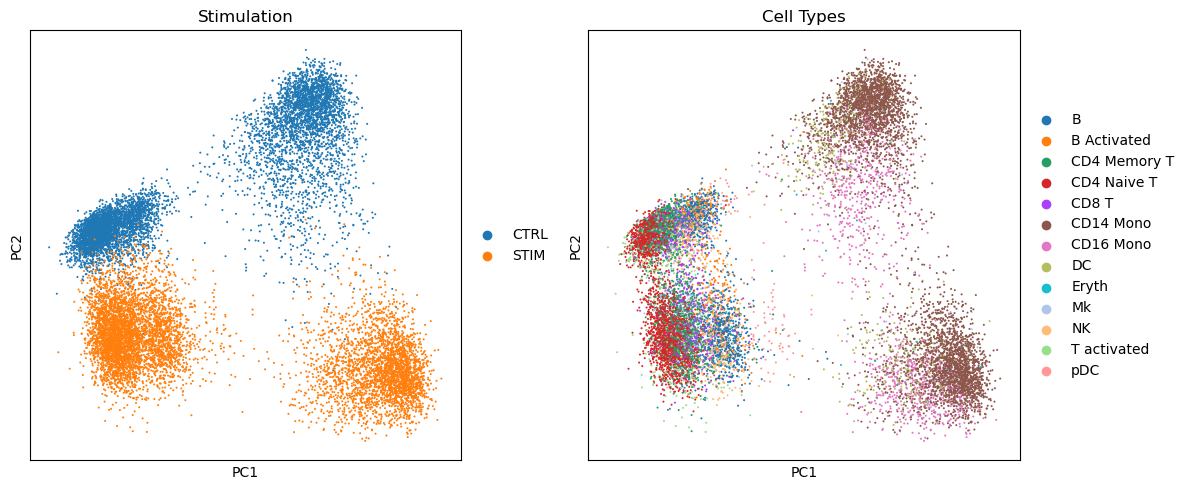

In [9]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5))

# sc.pl.umap(adata, color='leiden', ax = ax[0], show = False)
# ax[0].set_title('Clusters')
# ax[0].legend().set_visible(False)
# # ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(adata, color='stim', ax = ax[0], show = False)
ax[0].set_title('Stimulation')
# ax[1].legend().set_visible(False)

sc.pl.pca(adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
# ax[1].legend().set_visible(False)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

In [10]:
distance_df = cross_condition_distances(adata = tf_adata, 
                            column_1 = 'seurat_annotations', 
                            column_2 = 'stim', 
                            n_pcs = tf_adata.uns['pca']['pca_rank'])
distance_df.sort_values(by = 'distance', ascending = False).reset_index(drop = True)

,seurat_annotations,stim_1,stim_2,distance
0,CD14 Mono,CTRL,STIM,6.019051
1,DC,CTRL,STIM,5.435884
2,B,CTRL,STIM,5.358378
3,CD16 Mono,CTRL,STIM,4.933902
4,pDC,CTRL,STIM,4.871000
5,CD4 Naive T,CTRL,STIM,4.651253
6,NK,CTRL,STIM,4.379271
7,CD4 Memory T,CTRL,STIM,4.231110
8,Eryth,CTRL,STIM,4.192032
9,Mk,CTRL,STIM,3.934170


In [11]:
backup_tf_adata = tf_adata.copy()

In [12]:
subset_cells = []
n_cells = 100

for ct in tf_adata.obs['seurat_annotations'].unique():
    cells = tf_adata.obs[tf_adata.obs['seurat_annotations'] == ct].index.tolist()
    if len(cells) > n_cells:
        np.random.seed(seed)
        cells = list(np.random.choice(cells, n_cells, replace = False))
    subset_cells += cells
len(subset_cells)

1255

In [13]:
tf_adata = tf_adata[subset_cells, :]
adata = adata[subset_cells, :]

n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, 4)).astype(int)[1:-1])

In [14]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,45,45,54,31,43,48,45,57,23,55,49,51,37,583
STIM,55,55,46,69,57,52,55,43,32,45,51,49,63,672
Total,100,100,100,100,100,100,100,100,55,100,100,100,100,1255


In [15]:
tf_adata.obs['stim'].unique()

['STIM', 'CTRL']
Categories (2, object): ['CTRL', 'STIM']

In [16]:
test_cells = tf_adata.obs[(tf_adata.obs['seurat_annotations'] == 'B') & (tf_adata.obs['stim'] == 'STIM')].index.tolist()
train_cells = tf_adata.obs[~((tf_adata.obs['seurat_annotations'] == 'B') & (tf_adata.obs['stim'] == 'STIM'))].index.tolist()

ligand_input = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1'])
tf_output = pd.DataFrame(tf_adata.X, index = tf_adata.obs.index, columns = tf_adata.var.index)


In [20]:
me = 100
max_lr = 1e-3
lr_scaling_factor = 10
lr_period = 5

train_batch_factor = 4
test_batch_factor = 1

In [23]:
# linear scaling of inputs/outputs
projection_amplitude_in = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
lr_params = {'max_epochs': me, 'maximum_learning_rate': max_lr, 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(me/lr_period), 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': int(me/10)}

other_params = {'train_batch_size': round(len(train_cells)/train_batch_factor), 
                'test_batch_size': round(len(test_cells)/test_batch_factor), 'validation_batch_size': np.nan, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
target_spectral_radius = 0.8

In [24]:
projection_amplitude_out = 1

In [29]:
regularization_params = {'input_lambda_L2': 0, 
                         'bn_weights_lambda_l2': 0, 
                         'bn_bias_lambda_L2': 0, # 5e-8
                         'output_weights_lambda_L2': 0,
                         'output_bias_lambda_L2': 0,
                         'moa_lambda_L1': 0,  
                         'uniform_lambda_L2': 0,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 0,
                        'vae_lambda_l2': 0, 
                        'vae_scaling_KL': 1e-3}

# regularization_params = {'input_lambda_L2': 1e-4, 
#                          'bn_weights_lambda_l2': 1e-4, 
#                          'bn_bias_lambda_L2': 0, # 5e-8
#                          'output_weights_lambda_L2': 1e-4,
#                          'output_bias_lambda_L2': 1e-4,
#                          'moa_lambda_L1': 0,  
#                          'uniform_lambda_L2': 0,#, 1e-5,
#                          'uniform_min': 0,
#                          'uniform_max': 1, 
#                          'spectral_loss_factor': 0,
#                         'vae_lambda_l2': 1e-4, 
#                         'vae_scaling_KL': 1e-3}


discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': [768, 512, 256],
 'maximum_learning_rate': max_lr,
 'minimum_learning_rate':max_lr/lr_scaling_factor,
 'lr_restart_epoch': int(me/5),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 0, 
                       'discriminator_penalty_weight': 0.001}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}

In [30]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = adata.to_df(), 
                     covariates = tf_adata.obs,
                     categorical_covariate_keys = ['seurat_annotations'],
                     projection_amplitude_in = projection_amplitude_in, 
                     projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

In [31]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True,
                   track_validation = False)

In [32]:

mod = trainer.train_model(verbose = True)

# torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
# io.write_pickled_object(trainer,  os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))

  1%|▍                                          | 1/100 [00:02<03:33,  2.16s/it]

i=0, l(tr)=0.85245, l(te)=0.87962, s=0.21725, r=0.00010, v=0.00000


  2%|▊                                          | 2/100 [00:04<03:31,  2.16s/it]

i=1, l(tr)=0.69432, l(te)=0.80338, s=0.22901, r=0.00018, v=0.00000


  3%|█▎                                         | 3/100 [00:06<03:29,  2.16s/it]

...

i=97, l(tr)=0.47186, l(te)=0.54051, s=0.33244, r=0.00054, v=3006.50000


 99%|█████████████████████████████████████████▌| 99/100 [03:32<00:02,  2.16s/it]

i=98, l(tr)=0.46996, l(te)=0.54095, s=0.36324, r=0.00050, v=3013.25000


100%|█████████████████████████████████████████| 100/100 [03:34<00:00,  2.15s/it]

i=99, l(tr)=0.47204, l(te)=0.54344, s=0.37461, r=0.00046, v=3019.50000
Training ran in: 3 min 34.99 sec


In [33]:
train_stats_df = trainer.stats['train'].copy()
test_stats_df = trainer.stats['test'].copy()

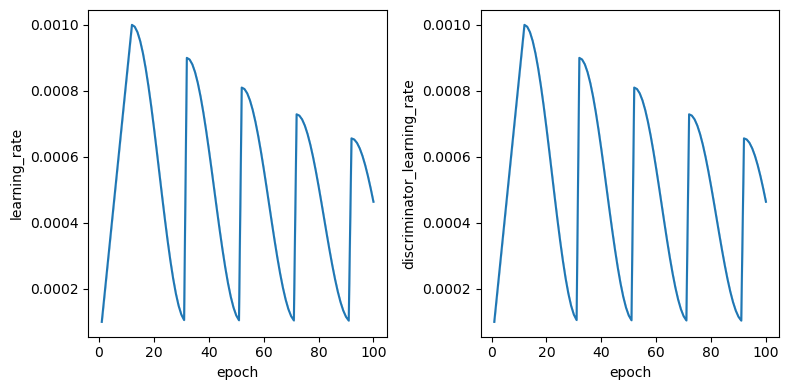

In [34]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
fig.tight_layout()

/tmp/ipykernel_2704906/3670132255.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()
/tmp/ipykernel_2704906/3670132255.py:45: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
/tmp/ipykernel_2704906/3670132255.py:58: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])


Text(0.5, 1.0, 'Train Loss - with Adverserial')

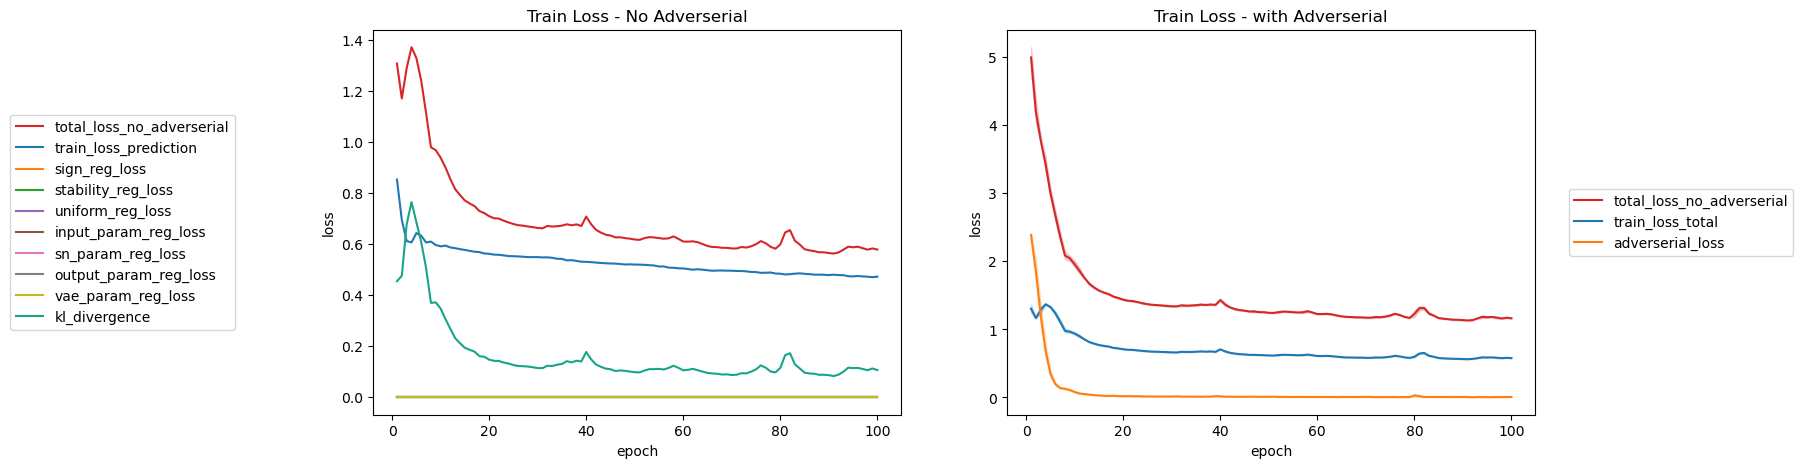

In [35]:
# font_scaling_factor = 1.2
# with plt.rc_context({
#     'font.size': plt.rcParams['font.size'] * font_scaling_factor,
#     'axes.titlesize': plt.rcParams['axes.titlesize'] * font_scaling_factor,
#     'axes.labelsize': plt.rcParams['axes.labelsize'] * font_scaling_factor,
#     'xtick.labelsize': plt.rcParams['xtick.labelsize'] * font_scaling_factor,
#     'ytick.labelsize': plt.rcParams['ytick.labelsize'] * font_scaling_factor,
#     'legend.fontsize': plt.rcParams['legend.fontsize'] * font_scaling_factor
# }):


fig, ax = plt.subplots(ncols = 2, figsize = (15,5))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']

viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

# TODO: delete this next line
viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
# ax[0].set_yscale('log')
ax[0].legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax[0].set_title('Train Loss - No Adverserial')


loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']
viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[0].set_yscale('log')
ax[1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[1].set_title('Train Loss - with Adverserial')
# ax[0].set_yscale('symlog')


In [38]:
viz_df.head()

,epoch,discriminator_loss_total,discriminator_loss_prediction,discriminator_param_reg_loss
0,1.0,2.712546,2.660901,0.051645
1,1.0,2.622940,2.571293,0.051647
2,1.0,2.571815,2.520166,0.051650
3,1.0,2.420724,2.369072,0.051652
4,2.0,2.261542,2.209887,0.051656


/tmp/ipykernel_2704906/1983991382.py:10: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)


Text(0.5, 1.0, 'Discriminator Loss')

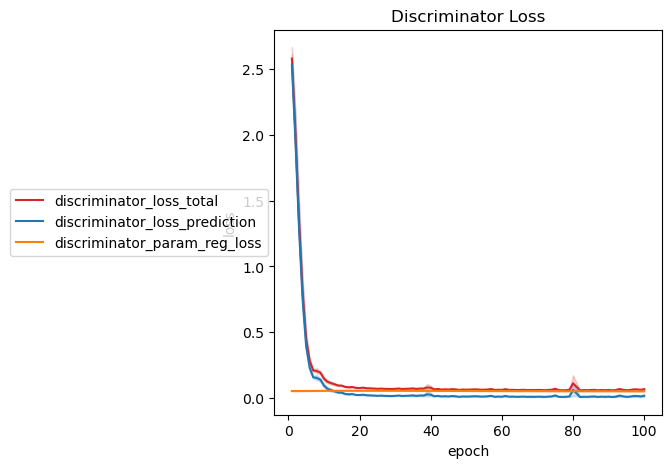

In [36]:
fig, ax = plt.subplots(ncols = 1, figsize = (5,5))


loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']
viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax[0].set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Discriminator Loss')


In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 4))

g = sns.lineplot(data = train_stats_df, x = 'epoch', y = 'train_loss_prediction', ax = ax[0])
g = sns.lineplot(data = test_stats_df, x = 'epoch', y = 'test_loss_prediction', ax = ax[0])
ax[0].set_ylabel('MSE Loss')
ax[0].set_xlabel('Epoch')
# ax[0].set_yscale('log')

g = sns.lineplot(data = train_stats_df, x = 'epoch', y = 'train_pearson', ax = ax[1])
g = sns.lineplot(data = test_stats_df, x = 'epoch', y = 'test_pearson', ax = ax[1])
ax[1].set_title('Full TF Activity Space')
ax[1].set_ylabel('Sample-Wise Pearson Correlation')
ax[1].set_ylim([-1,1])
ax[1].set_xlabel('Epoch')

fig.suptitle('Best Hyperparameters')
fig.tight_layout()
;


In [260]:
# # inputs
# X_train = mod.df_to_tensor(trainer.X_train)
# y_train = mod.df_to_tensor(trainer.y_train)
# expr_train = mod.df_to_tensor(mod.expr.loc[trainer.X_train.index, :])
# covariates_idx_train = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_train.index)

# # run prediction
# mod.eval()
# with torch.inference_mode():
#     Y_hat, Y_full, biases = mod(X_in = X_train, covariates_idx = covariates_idx_train, expr = expr_train)
#     bias_global, bias_mu, bias_log_sigma_squared = biases

# # formatting
# y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
# y_predicted.index, y_predicted.columns = trainer.y_train.index, trainer.y_train.columns

In [258]:
pearson_distance_a = calculate_pairwise_distances(Y_hat_df, 
                                                trainer.y_train, 
                                                axis = 0, 
                                                distance_metric = 'spearman',
                                                invert_corr = True).values.flatten()

# control
pearson_distance_b = calculate_pairwise_distances(trainer.y_train,
                                                  trainer.y_train,
                                                  axis = 0,
                                                  distance_metric = 'spearman',
                                                  invert_corr = True).values
pearson_distance_b = get_upper_triangle(pearson_distance_b)

pearson_distance_c = calculate_pairwise_distances(trainer.y_train,
                                                  trainer.y_test,
                                                  axis = 0,
                                                  distance_metric = 'spearman',
                                                  invert_corr = True).values.flatten()

In [ ]:
viz_df = pd.DataFrame(data = {'Actual vs Pred', 'Actual vs'})

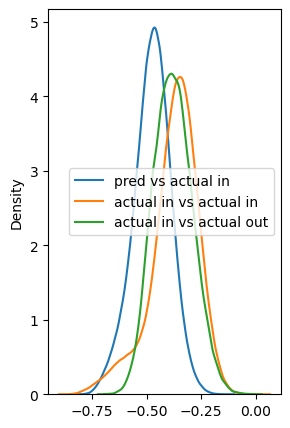

In [259]:
fig, ax = plt.subplots(figsize = (3, 5))
sns.kdeplot(pearson_distance_a, ax = ax, label = 'pred vs actual in')
sns.kdeplot(pearson_distance_b, ax = ax, label = 'actual in vs actual in')
sns.kdeplot(pearson_distance_c, ax = ax, label = 'actual in vs actual out')
ax.legend()

In [232]:
pearson_distance_a.values.flatten()

array([-0.6997291 , -0.7201344 , -0.6513093 , ..., -0.63565975,
       -0.5159729 , -0.6030885 ], dtype=float32)

In [228]:
import numpy as np

# Example numpy array
array = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])

# Get the indices for the upper triangle without the diagonal
upper_triangle_indices = np.triu_indices(array.shape[0], k=1)

# Extract the upper triangle values as a flat vector
upper_triangle_values = array[upper_triangle_indices]

print(upper_triangle_values)


[2 3 6]


In [225]:
upper_triangle_indices = np.triu_indices(df1.values.shape[0], k=1)

# Extract the upper triangle values as a flat vector
upper_triangle_values = df1.values[upper_triangle_indices]

In [226]:
upper_triangle_values

array([-0.67086101, -0.03304808,  0.84205453, -0.14288712, -0.73409432,
        0.06689785,  0.7989552 ,  0.1168607 ,  0.83209471, -0.30515444])

In [43]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

In [50]:
help(trainer.get_pearson_correlation)

Help on function get_pearson_correlation in module scLEMBAS.model.train:

get_pearson_correlation(tensor_a, tensor_b, axis=0, return_mean=True)
    Takes the row- or column-wise Pearson correlation between two torch tensors
    
    Parameters
    ----------
    tensor_a : _type_
        _description_
    tensor_b : _type_
        _description_
    axis : int, optional
        row-wise if 0, column-wise if 1, by default 0
    return_mean : bool, optional
        whether to take the mean across all correlations, by default True



In [49]:
y_train

tensor([[-0.6357,  1.0344,  1.0982,  ...,  0.1278, -1.6346,  0.2106],
        [-0.7281,  0.7981,  0.7489,  ..., -0.4117,  0.0092,  0.2214],
        [-0.3690,  0.5702,  0.8859,  ..., -0.5665,  0.0818, -0.1711],
        ...,
        [-0.7570,  0.8125,  0.8895,  ...,  0.0710,  0.1248,  0.0267],
        [ 0.6849,  0.4051,  0.2067,  ...,  0.2614,  0.3928,  0.1029],
        [ 0.1157,  0.3636,  1.5365,  ..., -0.6039,  0.5871, -0.2648]],
       device='cuda:0')

In [46]:
pearsons

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [ ]:
# import torch

# def spearman_corrcoef_columnwise(x, y):
#     # Ensure tensors are 2D and have the same shape
#     assert x.ndim == 2 and y.ndim == 2, "Both tensors must be 2-dimensional."
#     assert x.shape == y.shape, "Tensors must have the same shape."

#     # Get the number of columns
#     n_cols = x.shape[1]
    
#     # Initialize a tensor to store the Spearman correlations for each column
#     spearman_correlations = torch.zeros(n_cols)
    
#     with torch.no_grad():
#         for i in range(n_cols):
#             # Compute ranks for the i-th column of both tensors
#             x_rank = x[:, i].argsort().argsort().float()
#             y_rank = y[:, i].argsort().argsort().float()

#             # Standardize the ranks
#             x_rank -= x_rank.mean()
#             y_rank -= y_rank.mean()

#             # Compute the Spearman correlation for the i-th column
#             numerator = torch.sum(x_rank * y_rank)
#             denominator = torch.sqrt(torch.sum(x_rank ** 2) * torch.sum(y_rank ** 2))
#             spearman_correlations[i] = numerator / denominator

#     return spearman_correlations

# spearmans = spearman_corrcoef_columnwise(Y_hat, y_train).numpy()


In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots()
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')

# sns.histplot(spearmans, ax = ax)
;

In [ ]:
pca_mod = tf_adata.uns['pca']['pca_mod']
rank = tf_adata.uns["pca"]['pca_rank']


md = tf_adata.obs
md['condition'] = tf_adata.obs['seurat_annotations'].astype(str) + '^' + tf_adata.obs['stim'].astype(str)

X_pca = pd.DataFrame(tf_adata.obsm['X_pca'][:, :rank], 
                 index = tf_adata.obs.index, 
                columns = ['PC_{}'.format(i + 1) for i in range(rank)])
clf = NearestCentroid()
clf.fit(X_pca, md['condition'])
X_pca_centroids = pd.DataFrame(clf.centroids_, columns = clf.feature_names_in_, index = clf.classes_)

In [ ]:
viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()



In [ ]:
# inputs
X_test = mod.df_to_tensor(trainer.X_test)
y_test = mod.df_to_tensor(trainer.y_test)
expr_test = mod.df_to_tensor(mod.expr.loc[trainer.X_test.index, :])
covariates_idx_test = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_test.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_test.index, trainer.y_test.columns

In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_test, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots(figsize = (4,3))
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')
;

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_test.index, :], pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()